# Capstone Project: Day 6 - Advanced Analytics + Risk Metrics

**Objective:** Implement advanced financial metrics like Value at Risk (VaR), Rolling Sharpe, Sector Concentration (HHI), and Investor Cohort Analysis.

- **VaR & CVaR:** Worst-case daily loss analysis.
- **Rolling Sharpe Ratio:** Evaluating risk-adjusted return consistency over 90-day windows.
- **Sector HHI:** Measuring portfolio diversification vs concentration risk.
- **Cohort Analysis:** Understanding investor behaviors based on join year.
- **SIP Continuity:** Identifying at-risk investors with long gaps between SIPs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data/processed', exist_ok=True)

### 1. Value at Risk (VaR) & Conditional VaR (CVaR)

In [2]:
nav_path = '../data/raw/02_nav_history.csv'
if os.path.exists(nav_path):
    df_nav = pd.read_csv(nav_path)
    df_nav['date'] = pd.to_datetime(df_nav['date'])
    df_nav = df_nav.sort_values(['amfi_code', 'date'])
    df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()
    
    def compute_var_cvar(returns, conf_level=0.05):
        returns = returns.dropna()
        if len(returns) == 0: return pd.Series({'VaR_95': np.nan, 'CVaR_95': np.nan})
        var = np.percentile(returns, conf_level * 100)
        cvar = returns[returns <= var].mean()
        return pd.Series({'VaR_95': var, 'CVaR_95': cvar})
        
    risk_report = df_nav.groupby('amfi_code')['daily_return'].apply(compute_var_cvar).unstack()
    risk_report.to_csv('../data/processed/var_cvar_report.csv')
    print("VaR and CVaR saved.")
    display(risk_report.head())

VaR and CVaR saved.


,VaR_95,CVaR_95
amfi_code,,
100016,-0.014364,-0.018060
100025,-0.003793,-0.004994
100033,-0.019034,-0.023456
101206,-0.013282,-0.017439
101207,-0.026021,-0.032459


### 2. Rolling 90-day Sharpe Ratio

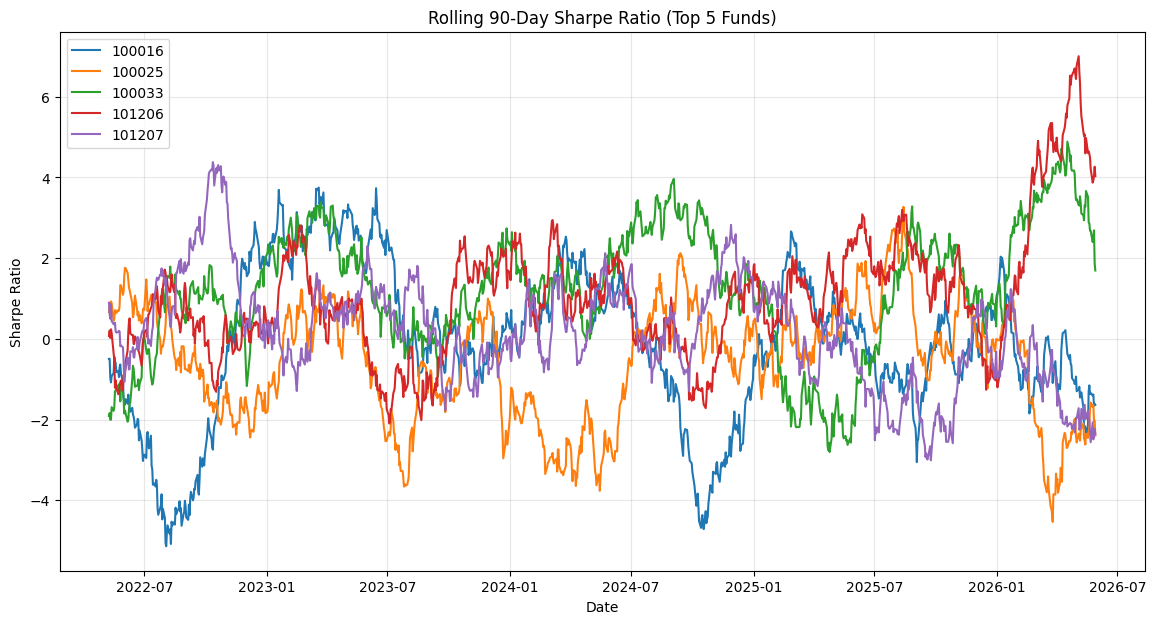

Rolling Sharpe chart saved.


In [3]:
if 'df_nav' in locals():
    # Pick top 5 funds by AUM or just arbitrary 5 for the chart
    top_funds = df_nav['amfi_code'].unique()[:5]
    
    plt.figure(figsize=(14, 7))
    for code in top_funds:
        fund_data = df_nav[df_nav['amfi_code'] == code].set_index('date')
        if not fund_data.empty:
            # rolling sharpe = rolling_mean / rolling_std * sqrt(252)
            rolling_ret = fund_data['daily_return'].rolling(90).mean() * 252
            rolling_std = fund_data['daily_return'].rolling(90).std() * np.sqrt(252)
            rolling_sharpe = (rolling_ret - 0.065) / rolling_std
            plt.plot(rolling_sharpe.index, rolling_sharpe, label=str(code))
            
    plt.title('Rolling 90-Day Sharpe Ratio (Top 5 Funds)')
    plt.xlabel('Date')
    plt.ylabel('Sharpe Ratio')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('../data/processed/rolling_sharpe_chart.png', bbox_inches='tight')
    plt.show()
    print("Rolling Sharpe chart saved.")

### 3. Sector Concentration (HHI Index)

In [4]:
port_path = '../data/raw/09_portfolio_holdings.csv'
if os.path.exists(port_path):
    df_port = pd.read_csv(port_path)
    # HHI = Sum of squared weight percentages
    df_port['weight_sq'] = df_port['weight_pct'] ** 2
    hhi_report = df_port.groupby('amfi_code')['weight_sq'].sum().reset_index()
    hhi_report.rename(columns={'weight_sq': 'Sector_HHI'}, inplace=True)
    hhi_report.to_csv('../data/processed/sector_hhi.csv', index=False)
    print("Sector HHI saved.")
    display(hhi_report.head())

Sector HHI saved.


,amfi_code,Sector_HHI
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902


### 4. Investor Cohort Analysis & SIP Continuity

In [5]:
tx_path = '../data/raw/08_investor_transactions.csv'
if os.path.exists(tx_path):
    df_tx = pd.read_csv(tx_path)
    df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])
    
    # Cohort Analysis
    cohort_data = df_tx.groupby('investor_id')['transaction_date'].min().dt.year.reset_index()
    cohort_data.rename(columns={'transaction_date': 'Cohort_Year'}, inplace=True)
    
    df_merged = df_tx.merge(cohort_data, on='investor_id')
    cohort_analysis = df_merged.groupby('Cohort_Year').agg({
        'amount_inr': 'mean',
        'investor_id': 'nunique'
    }).rename(columns={'amount_inr': 'Avg_Transaction_INR', 'investor_id': 'Total_Investors'})
    cohort_analysis.to_csv('../data/processed/cohort_analysis.csv')
    print("Cohort Analysis saved.")
    
    # SIP Continuity Analysis
    # Filter only SIPs
    df_sip = df_tx[df_tx['transaction_type'].str.contains('SIP', case=False, na=False)].sort_values(['investor_id', 'transaction_date'])
    
    def check_continuity(group):
        if len(group) < 6:
            return pd.Series({'avg_gap_days': np.nan, 'at_risk': False})
        
        gaps = group['transaction_date'].diff().dt.days.dropna()
        avg_gap = gaps.mean()
        at_risk = any(gaps > 35) # True if any gap > 35 days
        return pd.Series({'avg_gap_days': avg_gap, 'at_risk': at_risk})
        
    continuity = df_sip.groupby('investor_id').apply(check_continuity).reset_index()
    continuity.to_csv('../data/processed/sip_continuity.csv', index=False)
    print("SIP Continuity Analysis saved.")
    display(continuity.head())

Cohort Analysis saved.
SIP Continuity Analysis saved.


,investor_id,avg_gap_days,at_risk
0,INV000001,NaN,False
1,INV000002,NaN,False
2,INV000003,NaN,False
3,INV000004,85.4,True
4,INV000005,NaN,False
